In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, stats
#from scipy import stats
#from dataquality import DataQuality as dq
import nfl_data_py as nfl
pd.set_option('display.max_rows', 500)


In [3]:
nfl.see_weekly_cols()
#df = nfl.import_seasonal_rosters(2024, columns)

Index(['player_id', 'player_name', 'player_display_name', 'position',
       'position_group', 'headshot_url', 'recent_team', 'season', 'week',
       'season_type', 'opponent_team', 'completions', 'attempts',
       'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards',
       'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards',
       'passing_yards_after_catch', 'passing_first_downs', 'passing_epa',
       'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards',
       'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost',
       'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions',
       'receptions', 'targets', 'receiving_yards', 'receiving_tds',
       'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards',
       'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa',
       'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share',
       'wopr', 'special_teams_tds', 'fantasy_points

# EXPLORATORY DATA ANALYSIS

In [9]:
seasons = range(2022,2023+1)
pbp_py = nfl.import_pbp_data(seasons)
#pbp_py.head()
#del season
#pbp_py = nfl.import_pbp_data(seasons)
#nfl_yr = [*range(2000,2024, 1)]


2022 done.
2023 done.
Downcasting floats.


In [10]:
#Create data set using year range
data = nfl.import_weekly_data(years = seasons, downcast= True )
pbp_py_run = pbp_py.query('play_type =="run" & rusher_id.notnull()').reset_index()
pbp_py_run.loc[pbp_py_run.rushing_yards.isnull(), "rushing_yards"] = 0

Downcasting floats.


In [11]:
pbp_py_run['season'].unique()

array([2022, 2023])

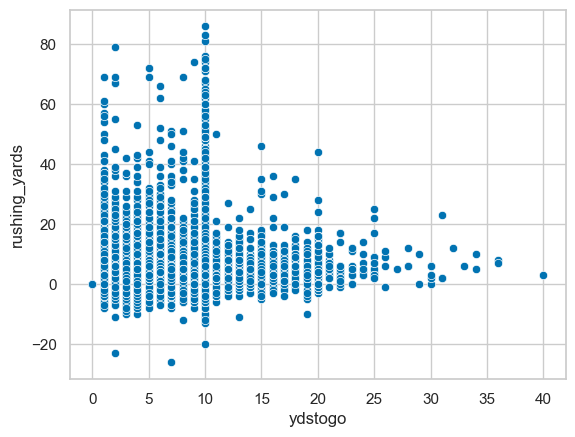

In [6]:
#RYOE = Rushing Yards Over Expected

sns.set_theme(style="whitegrid", palette="colorblind")
sns.scatterplot(data=pbp_py_run, x="ydstogo", y = "rushing_yards");
plt.show()

#This is a dense graph

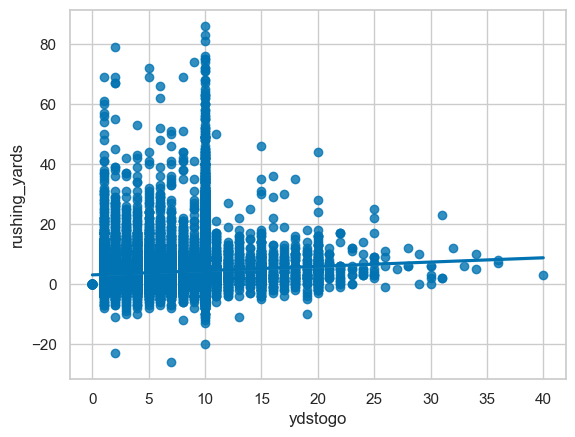

In [7]:
sns.regplot(data = pbp_py_run, x = "ydstogo", y= "rushing_yards")
plt.show()
#This show that rushing gains increase slightly as yards to go increases


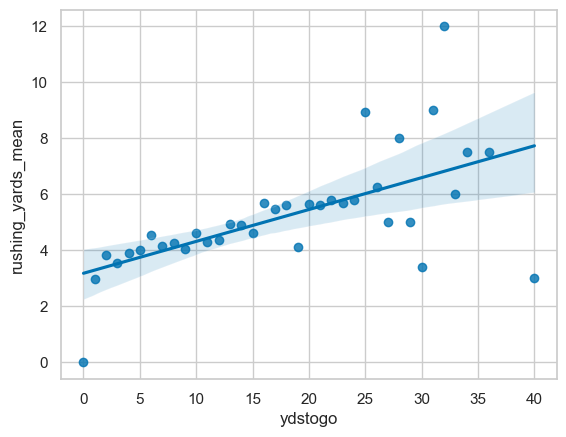

'This shows a positive linear relationship between average yards gained and yards to go. This approach can give you insight into whether\nthis worth doing in the first place and helps you to better see the data'

In [8]:
pbp_py_run_avg = pbp_py_run.groupby(["ydstogo"]).agg({"rushing_yards":["mean"]})
pbp_py_run_avg.columns = list(map("_".join, pbp_py_run_avg.columns))
pbp_py_run_avg.reset_index(inplace = True)
sns.regplot(data = pbp_py_run_avg, x = "ydstogo", y ="rushing_yards_mean")
plt.show()
'''This shows a positive linear relationship between average yards gained and yards to go. This approach can give you insight into whether
this worth doing in the first place and helps you to better see the data'''


# Simple Linear Regression

In [9]:
''' Simple linear regression, example ydstogo predicts rushing_yards, formula = (target) rushing_yards ~ 1+ ydstogo (predictor). 
Multiple predictors are separated by + sign 

rushing_yards are predicted by (~) intercept (1) and a slope parameter for yards to (ydstogo)

1 is an optional value to explicitly tell you where the model contains an intercept


'''

import statsmodels.formula.api as smf
yard_to_go_py = smf.ols(formula = 'rushing_yards ~ 1 + ydstogo', data = pbp_py_run)
print(yard_to_go_py.fit().summary())
#The output is a description of the model
#if R^2 = 1.0 then the model fits perfectly. In this exactly the model does not fit well 
#The Intercep is the number of rushing yards expected to  be gained if there are 0 yards to go for a first down or a touchdown ( which never occurs)
#The slope for ydstogo corresponds to the expected number of additional rushing yards expected to be gained for each additional yard to go
#Ex. Rushing play with 2 yards to go: 3.4 yards on average (y) = 0.1(m: slope) * 2(x: # of yards to go) + 3.2(b:intercept)

                            OLS Regression Results                            
Dep. Variable:          rushing_yards   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     222.1
Date:                Sun, 08 Sep 2024   Prob (F-statistic):           4.83e-50
Time:                        16:03:23   Log-Likelihood:                -89969.
No. Observations:               27857   AIC:                         1.799e+05
Df Residuals:                   27855   BIC:                         1.800e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.1575      0.083     37.915      0.0

In [10]:
#This provides the residuals which is the diffference between a model's expected (or predicted) output and the observed data.
#RYOE = Rushing Yards Over Expected
pbp_py_run["ryoe"] = yard_to_go_py.fit().resid
pbp_py_run.head()

,index,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,...,defense_players,n_offense,n_defense,ngs_air_yards,time_to_throw,was_pressure,route,defense_man_zone_type,defense_coverage_type,ryoe
0,2,68.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,...,00-0033294;00-0026190;00-0032574;00-0028278;00...,11.0,11.0,NaN,NaN,None,None,None,None,14.414349
1,4,115.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,...,00-0033294;00-0026190;00-0032574;00-0028278;00...,11.0,11.0,NaN,NaN,None,None,None,None,0.414349
2,9,254.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,...,00-0033463;00-0032109;00-0034384;00-0032759;00...,11.0,11.0,NaN,NaN,None,None,None,None,0.556877
3,10,275.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,...,00-0033463;00-0034384;00-0032109;00-0032759;00...,11.0,11.0,NaN,NaN,None,None,None,None,-4.585651
4,12,330.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,...,00-0032109;00-0034384;00-0037190;00-0035680;00...,11.0,11.0,NaN,NaN,None,None,None,None,-2.443123


In [11]:
'''
The count of RYOE is the number of carries a rusher has
The sum of RYOE is the RYOE
The mean of RYOE is the RYOE per carry
The mean of rushing yards is the yards per carry

'''


ryoe_py = pbp_py_run.groupby(['season', 'rusher_id', 'rusher']).agg({'ryoe':['count', 'sum', 'mean'], 'rushing_yards': 'mean'})
ryoe_py.columns = list(map('_'.join, ryoe_py.columns))
ryoe_py.reset_index(inplace=True)
ryoe_py = ryoe_py.rename(columns ={"ryoe_count":"n",
                                   "ryoe_sum":"ryoe_total",
                                  "ryoe_mean":"ryoe_per",
                                  "rushing_yards_mean":"yards_per_carry",}).query("n>50")
print(ryoe_py.sort_values("ryoe_total",ascending=False))

     season   rusher_id             rusher    n  ryoe_total  ryoe_per  \
706    2023  00-0039040           D.Achane  109  329.158272  3.019801   
427    2023  00-0033280        C.McCaffrey  331  327.258299  0.988696   
157    2022  00-0034796          L.Jackson   73  275.807492  3.778185   
305    2022  00-0036973          T.Etienne  251  224.835708  0.895760   
83     2022  00-0033293            A.Jones  213  205.952822  0.966915   
156    2022  00-0034791            N.Chubb  303  202.242789  0.667468   
212    2022  00-0035700           J.Jacobs  341  197.119042  0.578062   
87     2022  00-0033357             T.Hill   96  177.479469  1.848744   
713    2023  00-0039139            J.Gibbs  211  169.699426  0.804263   
189    2022  00-0035261          T.Pollard  214  168.800810  0.788789   
294    2022  00-0036906          K.Herbert  129  160.587779  1.244867   
299    2022  00-0036945           J.Fields   85  159.065600  1.871360   
79     2022  00-0033280        C.McCaffrey  286  15

In [24]:
n = ryoe_py.query("n > 50").to_string()
print(n)

     season   rusher_id             rusher    n  ryoe_total  ryoe_per  yards_per_carry
8      2022  00-0027966           M.Ingram   64  -42.058408 -0.657163         3.640625
28     2022  00-0030513           L.Murray  172   24.824004  0.144326         4.418605
30     2022  00-0030578        C.Patterson  144   83.366491  0.578934         4.826389
36     2022  00-0031376         J.McKinnon   91  -41.729900 -0.458570         3.857143
41     2022  00-0031687          R.Mostert  181  105.412925  0.582392         4.922652
49     2022  00-0032144           M.Gordon   90  -66.431034 -0.738123         3.533333
63     2022  00-0032764            D.Henry  349    6.730714  0.019286         4.406877
71     2022  00-0033045          E.Elliott  254 -152.065215 -0.598682         3.657480
75     2022  00-0033118            K.Drake  109   10.584412  0.097105         4.422019
79     2022  00-0033280        C.McCaffrey  286  157.620094  0.551119         4.814685
83     2022  00-0033293            A.Jones 

In [12]:
#keep only columns needed
cols_keep = ['season', 'rusher_id','rusher','ryoe_per', 'yards_per_carry']
#create current dataframe
ryoe_now_py = ryoe_py[cols_keep].copy()

#create last year's dataframe
ryoe_last_py = ryoe_py[cols_keep].copy()

#rename colums
ryoe_last_py.rename(columns = {'ryoe_per': 'ryoe_per_last', 'yards_per_carry': 'yards_per_carry_last'}, inplace = True)


In [13]:
#add 1 to season
ryoe_last_py['season'] += 1

#merge together
ryoe_lag_py = ryoe_now_py.merge(ryoe_last_py, how = 'inner', on =['rusher_id', 'rusher', 'season'])

In [34]:
#correlation for yards per carry
ryoe_lag_py[["yards_per_carry_last","yards_per_carry"]].corr()

,yards_per_carry_last,yards_per_carry
yards_per_carry_last,1.000000,0.531246
yards_per_carry,0.531246,1.000000


The results show that , for players with more than 50 rushing attempts in back-to-back seasons, 
this version of RYOE per carry is slightly more stable year to year than yards per carry (because the correlation coefficient is larger). Therefore,
yards per carry includes information inherent to the specific play in which a running back carries the ball. Furthermore , 
this information can vary from year to year. After extracted out, our new metric for running back performance is slightly more predictive 
year to year.


In [14]:
subjects = ['Excel', 'Presentations', 'SQL', 'Python', 'Tableau', 'AWS']
date = ['2023-01-02', '2023-01-16', '2023-01-30', '2023-02-13', '2023-02-27', '2023-03-13']
difficulty = [7, 5, 9, 10, 8, 8]
grade = [85, 90, 85, np.nan, np.nan, np.nan]

In [15]:
#dictionaryname = {key:values}
subj_info = {"subjects": subjects,
            "date":date}

subj_info




{'subjects': ['Excel', 'Presentations', 'SQL', 'Python', 'Tableau', 'AWS'],
 'date': ['2023-01-02',
  '2023-01-16',
  '2023-01-30',
  '2023-02-13',
  '2023-02-27',
  '2023-03-13']}